In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, log_loss, precision_score, recall_score
from sklearn.inspection import permutation_importance

In [2]:
# Loads data
file_path = r"../data/Micro-credit-Data-file.csv"
df = pd.read_csv(file_path).drop_duplicates()

print(f"Original Shape: {df.shape}")

# Drops Phone Number ID
df = df.drop('msisdn', axis=1)

# Removes possible leakage features
leakage_features = ['payback30', 'payback90']
df = df.drop(columns=leakage_features, errors='ignore')

# Handles Date safely
df['pdate'] = pd.to_datetime(df['pdate'])
df['pMonth'] = df['pdate'].dt.month
df['pDay'] = df['pdate'].dt.day
df = df.drop('pdate', axis=1)

print(f"Cleaned Shape: {df.shape}")
df.head()

Original Shape: (209593, 37)
Cleaned Shape: (209593, 35)


,Unnamed: 0,label,aon,daily_decr30,daily_decr90,rental30,rental90,last_rech_date_ma,last_rech_date_da,last_rech_amt_ma,...,amnt_loans30,maxamnt_loans30,medianamnt_loans30,cnt_loans90,amnt_loans90,maxamnt_loans90,medianamnt_loans90,pcircle,pMonth,pDay
0,1,0,272.0,3055.050000,3065.150000,220.13,260.13,2.0,0.0,1539,...,12,6.0,0.0,2.0,12,6,0.0,UPW,7,20
1,2,1,712.0,12122.000000,12124.750000,3691.26,3691.26,20.0,0.0,5787,...,12,12.0,0.0,1.0,12,12,0.0,UPW,8,10
2,3,1,535.0,1398.000000,1398.000000,900.13,900.13,3.0,0.0,1539,...,6,6.0,0.0,1.0,6,6,0.0,UPW,8,19
3,4,1,241.0,21.228000,21.228000,159.42,159.42,41.0,0.0,947,...,12,6.0,0.0,2.0,12,6,0.0,UPW,6,6
4,5,1,947.0,150.619333,150.619333,1098.90,1098.90,4.0,0.0,2309,...,42,6.0,0.0,7.0,42,6,0.0,UPW,6,22


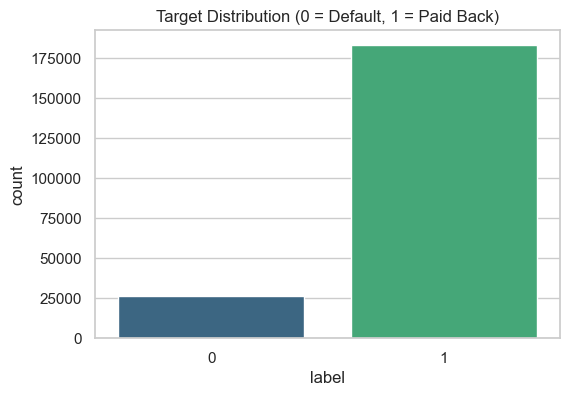

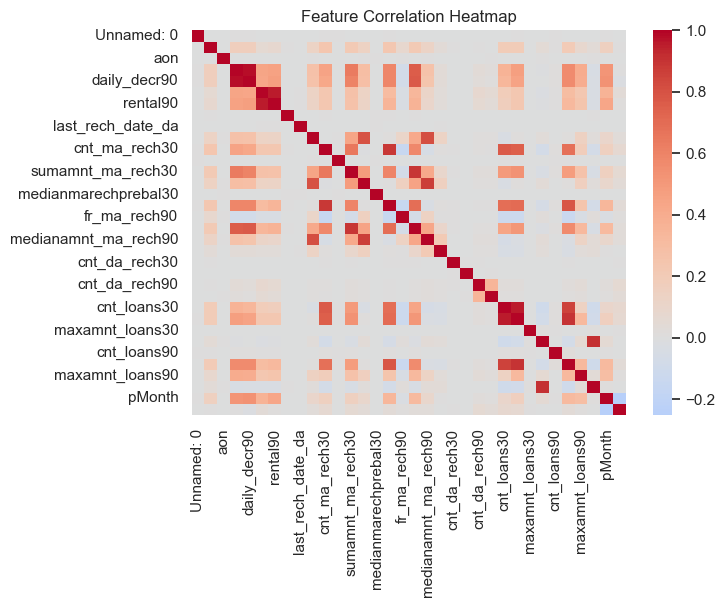

In [3]:
# Sets plot style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# Targets Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df, palette="viridis")
plt.title("Target Distribution (0 = Default, 1 = Paid Back)")
plt.show()

# Correlation Heatmap
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [4]:
# Separates Features and Target
X = df.drop("label", axis=1)
y = df["label"]

# Train/Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Custom Math Function
def engineer_features(X_data):
    X_out = X_data.copy()
    X_out["TotalLoanCount"] = X_out["cnt_loans30"] + X_out["cnt_loans90"]
    X_out["AvgLoanAmount30"] = np.where(X_out["cnt_loans30"] > 0, X_out["amnt_loans30"] / X_out["cnt_loans30"], 0)
    X_out["AvgLoanAmount90"] = np.where(X_out["cnt_loans90"] > 0, X_out["amnt_loans90"] / X_out["cnt_loans90"], 0)
    return X_out

# Pipeline Steps
feature_gen = FunctionTransformer(engineer_features)

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, make_column_selector(dtype_include=np.number)),
    ('cat', cat_transformer, make_column_selector(dtype_exclude=np.number))
])

In [5]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, solver="liblinear", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42, n_jobs=-1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
}

results = {}

for name, classifier in models.items():
    # pipeline for this model
    pipeline = Pipeline(steps=[
        ('feature_gen', feature_gen),
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    preds = pipeline.predict(X_val)
    probs = pipeline.predict_proba(X_val)[:, 1]
    
    # Log Results
    results[name] = {
        "ROC-AUC": roc_auc_score(y_val, probs),
        "Precision": precision_score(y_val, preds, zero_division=0),
        "Recall": recall_score(y_val, preds),
        "Log Loss": log_loss(y_val, probs)
    }

print("Initial Model Comparison:")
pd.DataFrame(results).T.sort_values(by="ROC-AUC", ascending=False)

Initial Model Comparison:


,ROC-AUC,Precision,Recall,Log Loss
Hist Gradient Boosting,0.936560,0.976817,0.853354,0.317501
Random Forest,0.925394,0.931962,0.980456,0.229442
Logistic Regression,0.832128,0.962870,0.692016,0.518224


In [6]:
# master pipeline with Random Forest
rf_pipeline = Pipeline(steps=[
    ('feature_gen', feature_gen),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

# Defines the grid
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=5,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("Best Parameters Found:")
print(search.best_params_)

Best Parameters Found:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}


ROC-AUC Score: 0.9316979188313336

Confusion Matrix:
 [[ 3145  2087]
 [ 1250 35437]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.60      0.65      5232
           1       0.94      0.97      0.96     36687

    accuracy                           0.92     41919
   macro avg       0.83      0.78      0.80     41919
weighted avg       0.92      0.92      0.92     41919


Calculating Permutation Importance...


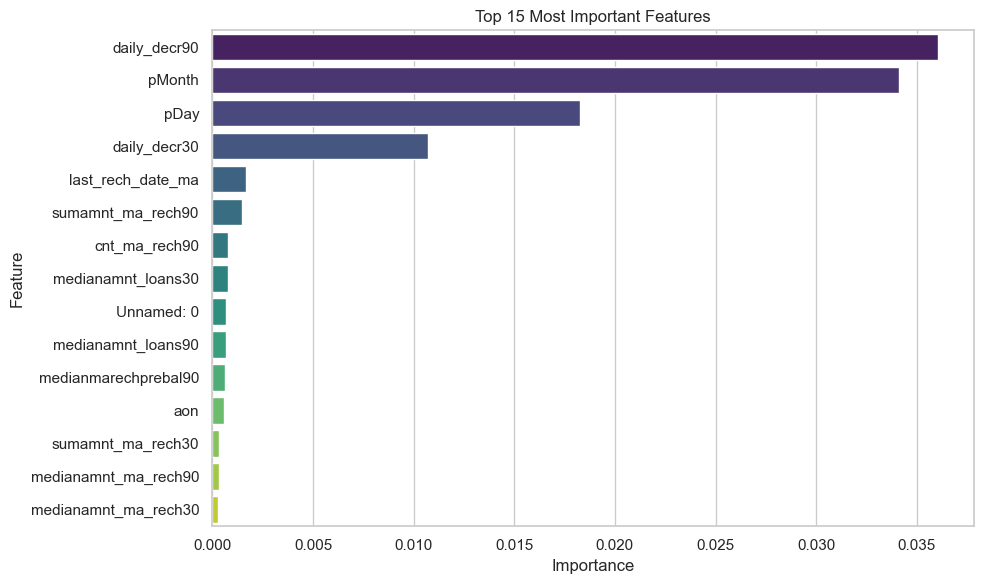

In [7]:
# Final Predictions
y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_val, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# Permutation Importance
print("\nCalculating Permutation Importance...")
result = permutation_importance(best_model, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=perm_df.head(15), x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Most Important Features")
plt.tight_layout()
plt.show()